In [1]:
import json
import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd

import openeo
from openeo.processes import if_

In [2]:
Tongeren_polygon = gpd.read_file("NUTS3_Tongeren.gpkg")
print(f"type: {type(Tongeren_polygon)} with crs: {Tongeren_polygon.crs}")

# load to 4326
Tongeren_polygon = Tongeren_polygon.to_crs("EPSG:4326")
print(f"type: {type(Tongeren_polygon)} with crs: {Tongeren_polygon.crs}")


type: <class 'geopandas.geodataframe.GeoDataFrame'> with crs: EPSG:3035
type: <class 'geopandas.geodataframe.GeoDataFrame'> with crs: EPSG:4326


In [3]:
# feature collection from geopandas dataframe
aoi = json.loads(Tongeren_polygon.to_json())

In [4]:
# Time window:
# - Season 1: August/2024 – Dec/2025 (the focus is the season Oct/2024 – Oct/2025, but it is good to have some data before and after to test the smoothing/gap filling algorithm)
# - Season 2: August/2025 – now (the focus is the season Oct/2025 – NRT)
season1 = ["2024-08-01", "2025-12-31"]
season2 = ["2025-08-01", "2026-08-31"]

In [5]:
connection = openeo.connect("openeo.terrascope.be").authenticate_oidc()

Authenticated using refresh token.


In [6]:
# load field from parcel delination
fields_2025 = gpd.read_file("AGRIPRC2025_Tongeren_selection.gpkg")
fields_2025 = fields_2025.to_crs("EPSG:4326")
subset_fields_2025 = fields_2025[:100]
print(f"length of fields_2025: {len(fields_2025)}")

# load field from parcel delination 2026
fields_2026 = gpd.read_file("AGRIPRC2026_Tongeren_selection.gpkg")
fields_2026 = fields_2026.to_crs("EPSG:4326")
subset_fields_2026 = fields_2026[:100]
print(f"length of fields_2026: {len(fields_2026)}")

length of fields_2025: 6780
length of fields_2026: 5951


In [7]:
def delinated_lai(temporal_extent, fields):
    s2_lai = connection.load_stac(
        url = "https://stac.terrascope.be/collections/terrascope-s2-lai-v2",
        spatial_extent = aoi,
        temporal_extent = temporal_extent,
        bands = ["LAI"],
        properties = {"gsd":lambda x: x==20}
    )
    scale = 0.04
    offset = 0

    s2_lai_scaled = s2_lai.apply(lambda x: x * scale + offset)
    
    delineated_map = s2_lai_scaled.filter_spatial(json.loads(fields.to_json()))
    return delineated_map
    

In [8]:
# aggregate to dekad to check the data before smoothing
delineated_map = delinated_lai(season1, subset_fields_2025)

without_smoothing = delineated_map.aggregate_temporal_period(reducer="mean", period="dekad")
deked_job_nosmooth = without_smoothing.create_job(
    title="LAI: 100 fields without smoothing",
    sample_by_feature=True,
    feature_id_property="AGPAKEY",
    out_format="NetCDF"
)
deked_job_nosmooth.start_and_wait()


0:00:00 Job 'j-2609061550344e19ac4998df794cb9d0': send 'start'
0:00:15 Job 'j-2609061550344e19ac4998df794cb9d0': created (progress 0%)
0:00:20 Job 'j-2609061550344e19ac4998df794cb9d0': queued (progress 0%)
0:00:27 Job 'j-2609061550344e19ac4998df794cb9d0': queued (progress 0%)
0:00:35 Job 'j-2609061550344e19ac4998df794cb9d0': queued (progress 0%)
0:00:45 Job 'j-2609061550344e19ac4998df794cb9d0': running (progress 5.2%)
0:00:58 Job 'j-2609061550344e19ac4998df794cb9d0': running (progress 7.1%)
0:01:13 Job 'j-2609061550344e19ac4998df794cb9d0': running (progress 9.2%)
0:01:33 Job 'j-2609061550344e19ac4998df794cb9d0': running (progress 11.8%)
0:01:57 Job 'j-2609061550344e19ac4998df794cb9d0': running (progress 14.9%)
0:02:27 Job 'j-2609061550344e19ac4998df794cb9d0': running (progress 18.3%)
0:03:05 Job 'j-2609061550344e19ac4998df794cb9d0': running (progress 22.3%)
0:03:51 Job 'j-2609061550344e19ac4998df794cb9d0': running (progress 26.7%)
0:04:50 Job 'j-2609061550344e19ac4998df794cb9d0': runni

<BatchJob job_id='j-2609061550344e19ac4998df794cb9d0'>

In [10]:
result = deked_job_nosmooth.get_results()
result.download_files("original_lai/")

[WindowsPath('original_lai/openEO_10260_1152548037.nc'),
 WindowsPath('original_lai/openEO_10260_1152550158.nc'),
 WindowsPath('original_lai/openEO_10260_1152577036.nc'),
 WindowsPath('original_lai/openEO_10260_1211993172.nc'),
 WindowsPath('original_lai/openEO_10260_1212630039.nc'),
 WindowsPath('original_lai/openEO_10260_1212632564.nc'),
 WindowsPath('original_lai/openEO_10260_1245229921.nc'),
 WindowsPath('original_lai/openEO_10260_1245381178.nc'),
 WindowsPath('original_lai/openEO_10260_1246397860.nc'),
 WindowsPath('original_lai/openEO_10260_1246398062.nc'),
 WindowsPath('original_lai/openEO_10260_1246801725.nc'),
 WindowsPath('original_lai/openEO_10260_1247870543.nc'),
 WindowsPath('original_lai/openEO_10260_1248024531.nc'),
 WindowsPath('original_lai/openEO_10260_1248462041.nc'),
 WindowsPath('original_lai/openEO_10260_1257280654.nc'),
 WindowsPath('original_lai/openEO_10260_1257280755.nc'),
 WindowsPath('original_lai/openEO_10260_1257281361.nc'),
 WindowsPath('original_lai/open

In [11]:
# apply Whittaker smoothing UDF along the temporal dimension
smoothed = delineated_map.apply_dimension(
    process=openeo.UDF.from_file("whittaker_udf.py"),
    dimension="t",
    context={"smoothing_lambda":10000, "prediction_period": 2},
)

# aggregate deaked after whittaker
smoothed_dekad = smoothed.aggregate_temporal_period(reducer="mean", period="dekad")
deked_job = smoothed_dekad.create_job(
    title="LAI: 100 fields with Whittaker smoothing",
    sample_by_feature=True,
    feature_id_property="AGPAKEY",
    out_format="NetCDF"
)
deked_job.start_and_wait()

0:00:00 Job 'j-2609061559414186a4e4a5d75c5ea2e4': send 'start'
0:00:13 Job 'j-2609061559414186a4e4a5d75c5ea2e4': created (progress 0%)
0:00:18 Job 'j-2609061559414186a4e4a5d75c5ea2e4': queued (progress 0%)
0:00:24 Job 'j-2609061559414186a4e4a5d75c5ea2e4': queued (progress 0%)
0:00:33 Job 'j-2609061559414186a4e4a5d75c5ea2e4': queued (progress 0%)
0:00:44 Job 'j-2609061559414186a4e4a5d75c5ea2e4': running (progress 5.2%)
0:00:57 Job 'j-2609061559414186a4e4a5d75c5ea2e4': running (progress 7.0%)
0:01:12 Job 'j-2609061559414186a4e4a5d75c5ea2e4': running (progress 9.2%)
0:01:31 Job 'j-2609061559414186a4e4a5d75c5ea2e4': running (progress 11.8%)
0:01:56 Job 'j-2609061559414186a4e4a5d75c5ea2e4': running (progress 14.8%)
0:02:26 Job 'j-2609061559414186a4e4a5d75c5ea2e4': running (progress 18.3%)
0:03:03 Job 'j-2609061559414186a4e4a5d75c5ea2e4': running (progress 22.3%)
0:03:50 Job 'j-2609061559414186a4e4a5d75c5ea2e4': running (progress 26.7%)
0:04:49 Job 'j-2609061559414186a4e4a5d75c5ea2e4': runni

<BatchJob job_id='j-2609061559414186a4e4a5d75c5ea2e4'>

In [12]:
result = deked_job.get_results()
result.download_files("smoothed_lai/")

[WindowsPath('smoothed_lai/openEO_10260_1152548037.nc'),
 WindowsPath('smoothed_lai/openEO_10260_1152550158.nc'),
 WindowsPath('smoothed_lai/openEO_10260_1152577036.nc'),
 WindowsPath('smoothed_lai/openEO_10260_1211993172.nc'),
 WindowsPath('smoothed_lai/openEO_10260_1212630039.nc'),
 WindowsPath('smoothed_lai/openEO_10260_1212632564.nc'),
 WindowsPath('smoothed_lai/openEO_10260_1245229921.nc'),
 WindowsPath('smoothed_lai/openEO_10260_1245381178.nc'),
 WindowsPath('smoothed_lai/openEO_10260_1246397860.nc'),
 WindowsPath('smoothed_lai/openEO_10260_1246398062.nc'),
 WindowsPath('smoothed_lai/openEO_10260_1246801725.nc'),
 WindowsPath('smoothed_lai/openEO_10260_1247870543.nc'),
 WindowsPath('smoothed_lai/openEO_10260_1248024531.nc'),
 WindowsPath('smoothed_lai/openEO_10260_1248462041.nc'),
 WindowsPath('smoothed_lai/openEO_10260_1257280654.nc'),
 WindowsPath('smoothed_lai/openEO_10260_1257280755.nc'),
 WindowsPath('smoothed_lai/openEO_10260_1257281361.nc'),
 WindowsPath('smoothed_lai/open

In [13]:
def plot_lai_per_crop_type(data_folder, subset_data):
    for crop_type in subset_data['MAINCROP'].unique():
        crop_subset = subset_data[subset_data['MAINCROP'] == crop_type]
        #load netcdf data for each crop type
        fig, ax = plt.subplots(figsize=(12, 6))
        netcdf_data = {row['AGPAKEY']: f"{data_folder}/openEO_{row['AGPAKEY']}.nc" for index, row in crop_subset.iterrows()}
        for agpakey, filepath in netcdf_data.items():

            # Open lazily — does not load the whole file into RAM
            ds = xr.open_dataset(filepath)

            # Spatial mean for every timestep
            ts = ds["LAI"].mean(dim=["x", "y"])

            # Load only the resulting time series
            ts = ts.load()

            # Plot
            ax.plot(
                ts["t"],
                ts,
                label=str(agpakey),
                # color='g'
            )

            ds.close()

        ax.set_xlabel("Time")
        ax.set_ylabel("Mean value")
        ax.set_title(f"Mean lai for {crop_type}")
        plt.show()

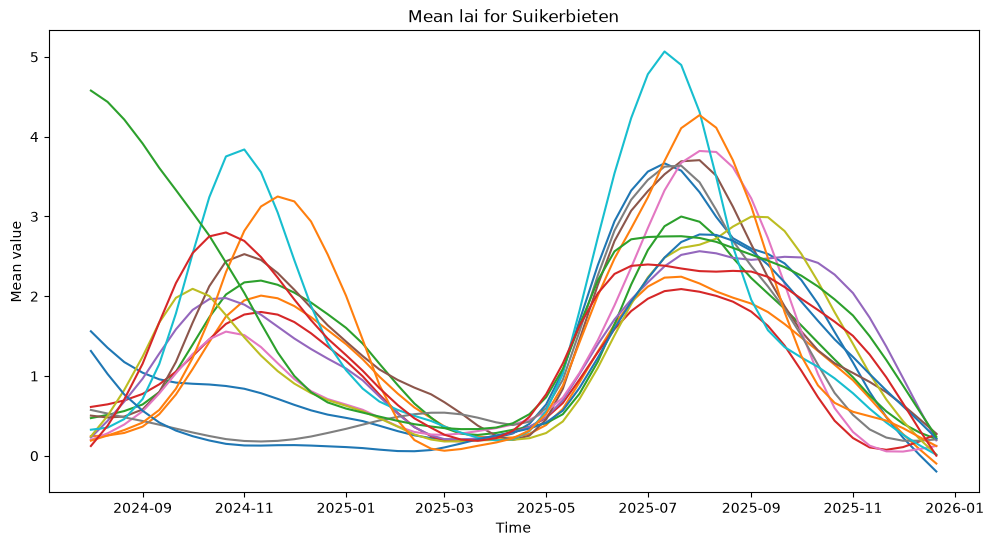

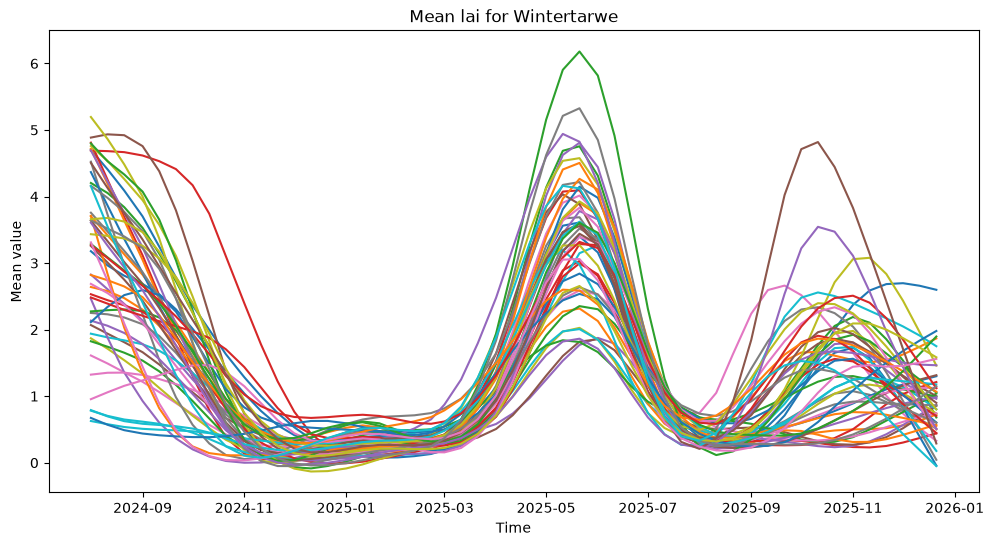

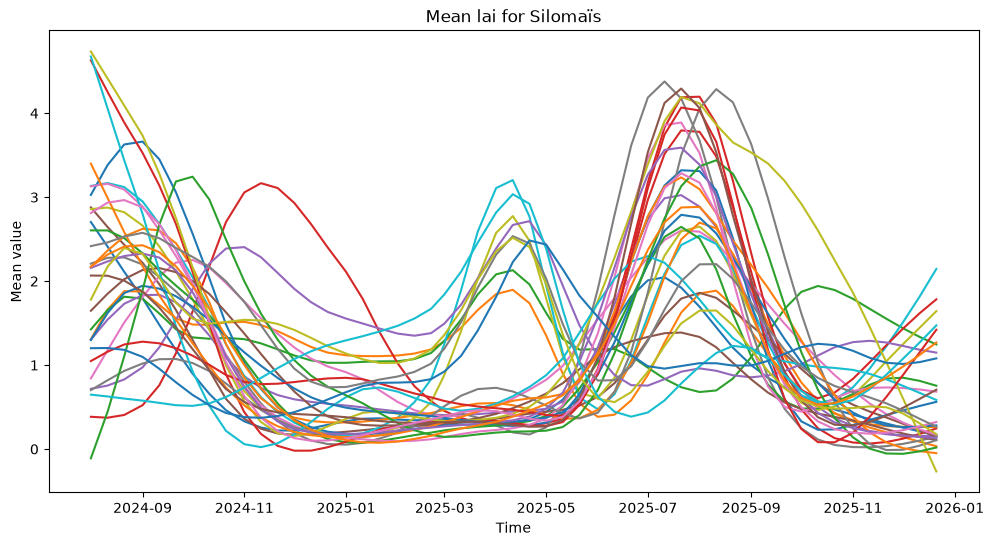

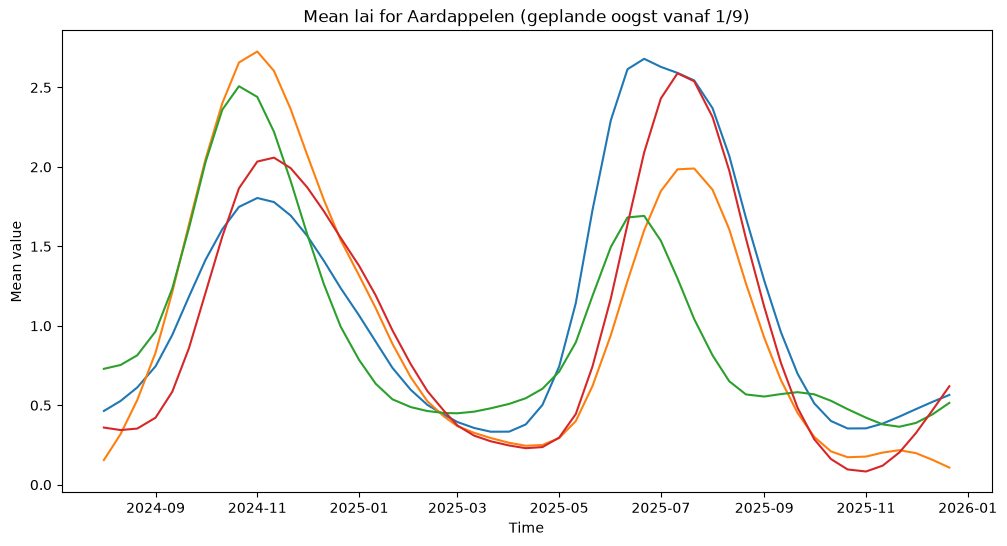

In [15]:
# season 1
data_folder = "smoothed_lai"
subset_data = subset_fields_2025[['AGPAKEY','MAINCROP']]
plot_lai_per_crop_type(data_folder, subset_data)

In [18]:
def plot_smoothening_effect(pre_data, post_data, subset_data):
    for crop_type in subset_data['MAINCROP'].unique():
        crop_subset = subset_data[subset_data['MAINCROP'] == crop_type]
        #load netcdf data for each crop type
        fig, ax = plt.subplots(figsize=(12, 6))
        netcdf_data = {row['AGPAKEY']: f"{post_data}/openEO_{row['AGPAKEY']}.nc" for index, row in crop_subset.iterrows()}
        i=0
        for index, row in crop_subset.iterrows():

            # Open lazily — does not load the whole file into RAM
            agpakey = row['AGPAKEY']
            ds_pre = xr.open_dataset(f"{pre_data}/openEO_{agpakey}.nc")
            ds_post = xr.open_dataset(f"{post_data}/openEO_{agpakey}.nc")

            # Spatial mean for every timestep
            ts_pre = ds_pre["LAI"].mean(dim=["x", "y"])
            ts_post = ds_post["LAI"].mean(dim=["x", "y"])

            # Load only the resulting time series
            ts_pre = ts_pre.load()
            ts_post = ts_post.load()

            # Plot
            ax.plot(
                ts_pre["t"],
                ts_pre,
                label=f"{agpakey} (pre)",
                color='gray',
                marker='o', 
            )
            ax.plot(
                ts_post["t"],
                ts_post,
                label=f"{agpakey} (post)",
                color='green'
            )

            ds_pre.close()
            ds_post.close()
            # just plot one for diagnostic purposes
            # break
            i += 1
            if i >= 3:
                break

        ax.set_xlabel("Time")
        ax.set_ylabel("Mean value")
        ax.set_title(f"Smoothing Effect for {crop_type}")
        ax.legend(labels=['Before Smoothing', 'After Smoothing'])
        plt.show()
    

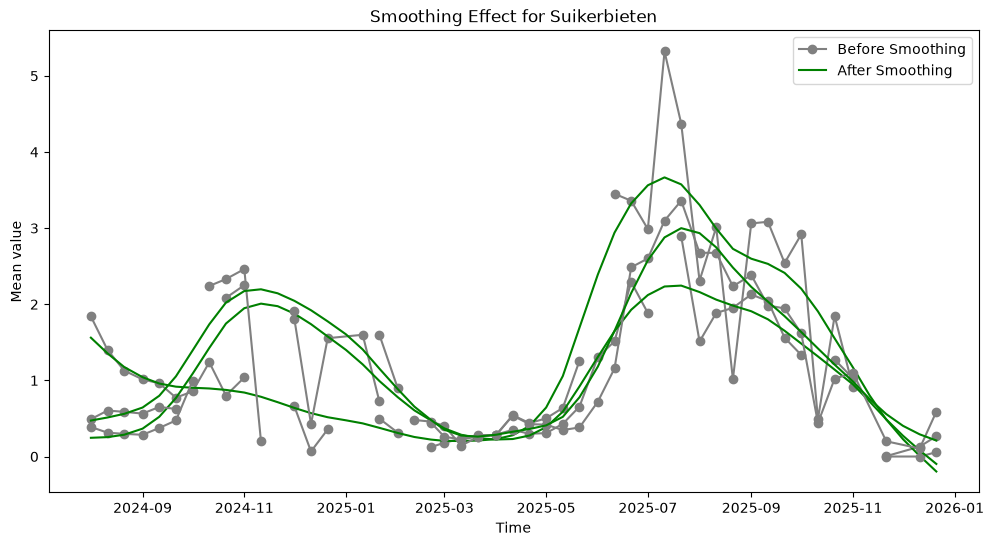

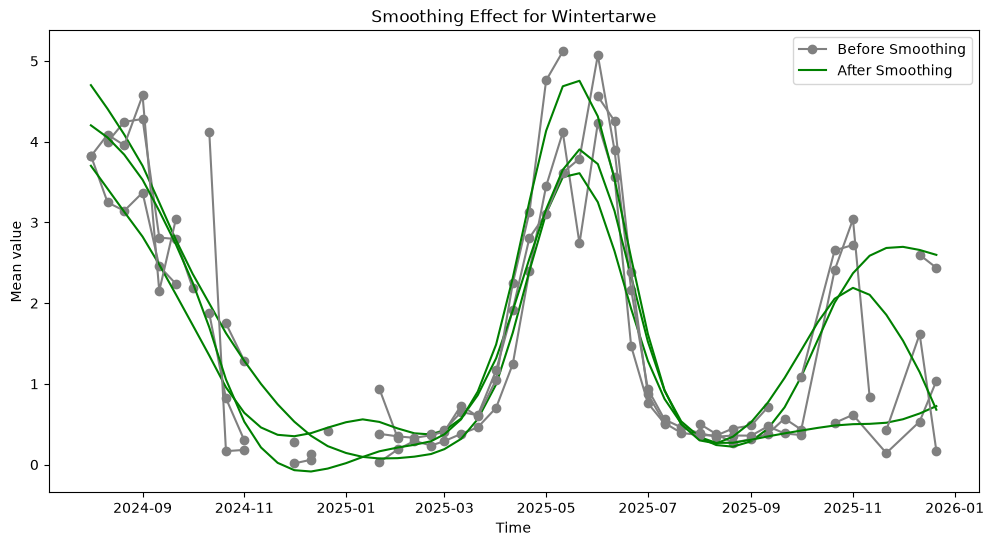

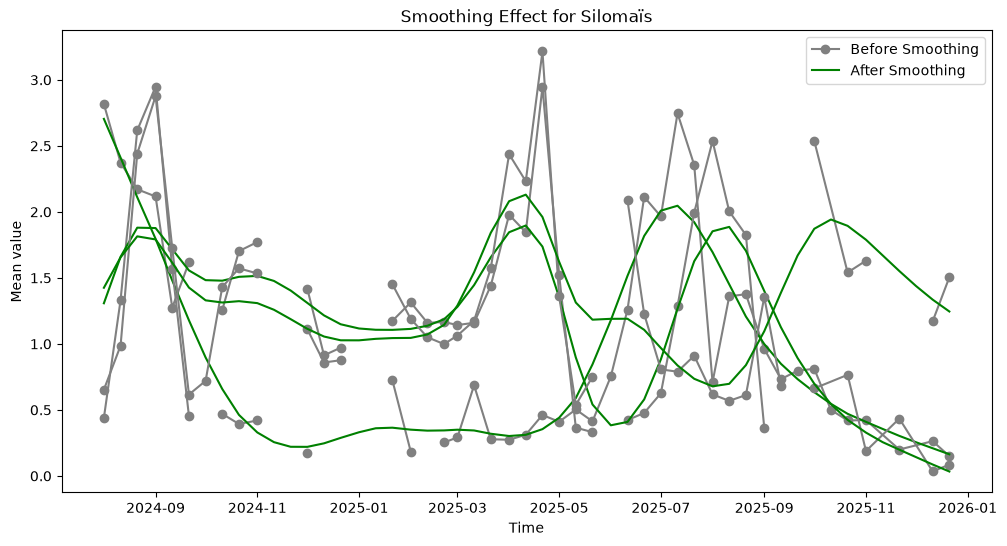

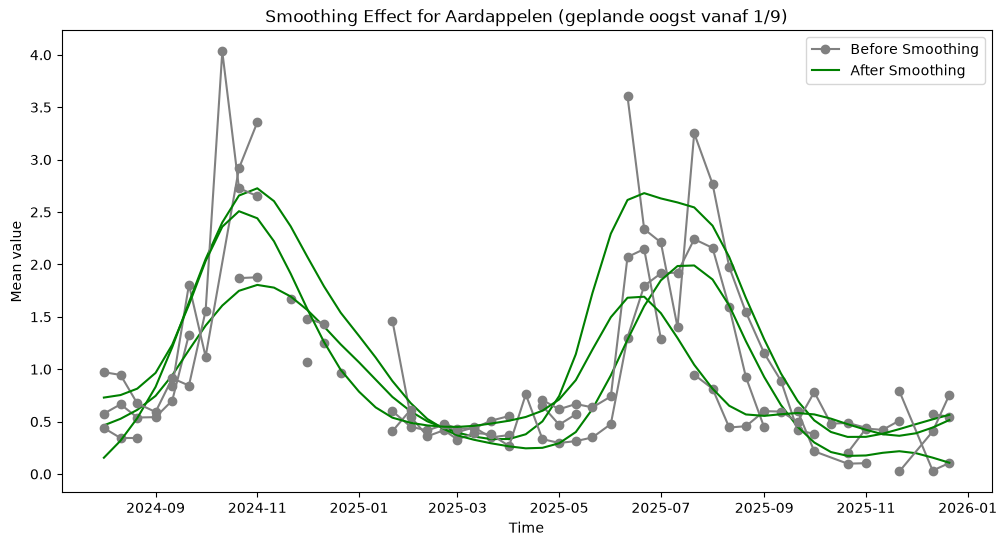

In [19]:
pre_data = "original_lai"
post_data = "smoothed_lai"
subset_data = fields_2025[['AGPAKEY','MAINCROP']]
plot_smoothening_effect(pre_data, post_data, subset_data)

Quality layers: count valid observations along time before and after smoothing.
count_time() counts non-nodata values and preserves the spatial dimensions.

In [20]:
# delineated_map: deaked aggregation not done yet
# smoothed: whittaker smoothing done deaked aggregation not done yet

valid_before = delineated_map.count_time().rename_labels("bands", ["valid_before"])
all_valid_before = delineated_map.apply(lambda x: if_(x.is_nodata(), 0, x))
total_before = all_valid_before.count_time().rename_labels("bands", ["total_before"])

valid_after = smoothed.count_time().rename_labels("bands", ["valid_after"])
all_valid_after = smoothed.apply(lambda x: if_(x.is_nodata(), 0, x))
total_after = all_valid_after.count_time().rename_labels("bands", ["total_after"])

In [21]:
quality_layers = valid_before.merge_cubes(valid_after).merge_cubes(total_before).merge_cubes(total_after)
quality_job = quality_layers.create_job(
    title="LAI Quality Layers",
    sample_by_feature=True,
    feature_id_property="AGPAKEY",
    out_format="NetCDF"
)
quality_job.start_and_wait()

0:00:00 Job 'j-26090616140842059b14614cb34f3871': send 'start'
0:00:13 Job 'j-26090616140842059b14614cb34f3871': created (progress 0%)
0:00:19 Job 'j-26090616140842059b14614cb34f3871': queued (progress 0%)
0:00:25 Job 'j-26090616140842059b14614cb34f3871': queued (progress 0%)
0:00:33 Job 'j-26090616140842059b14614cb34f3871': queued (progress 0%)
0:00:43 Job 'j-26090616140842059b14614cb34f3871': running (progress 5.0%)
0:00:56 Job 'j-26090616140842059b14614cb34f3871': running (progress 6.8%)
0:01:11 Job 'j-26090616140842059b14614cb34f3871': running (progress 9.0%)
0:01:31 Job 'j-26090616140842059b14614cb34f3871': running (progress 11.6%)
0:01:55 Job 'j-26090616140842059b14614cb34f3871': running (progress 14.6%)
0:02:25 Job 'j-26090616140842059b14614cb34f3871': running (progress 18.1%)
0:03:02 Job 'j-26090616140842059b14614cb34f3871': running (progress 22.1%)
0:03:49 Job 'j-26090616140842059b14614cb34f3871': running (progress 26.6%)
0:04:48 Job 'j-26090616140842059b14614cb34f3871': runni

<BatchJob job_id='j-26090616140842059b14614cb34f3871'>

In [22]:
result = quality_job.get_results()
result.download_files("lai_quality_layers/")

[WindowsPath('lai_quality_layers/openEO_10260_1152548037.nc'),
 WindowsPath('lai_quality_layers/openEO_10260_1152550158.nc'),
 WindowsPath('lai_quality_layers/openEO_10260_1152577036.nc'),
 WindowsPath('lai_quality_layers/openEO_10260_1211993172.nc'),
 WindowsPath('lai_quality_layers/openEO_10260_1212630039.nc'),
 WindowsPath('lai_quality_layers/openEO_10260_1212632564.nc'),
 WindowsPath('lai_quality_layers/openEO_10260_1245229921.nc'),
 WindowsPath('lai_quality_layers/openEO_10260_1245381178.nc'),
 WindowsPath('lai_quality_layers/openEO_10260_1246397860.nc'),
 WindowsPath('lai_quality_layers/openEO_10260_1246398062.nc'),
 WindowsPath('lai_quality_layers/openEO_10260_1246801725.nc'),
 WindowsPath('lai_quality_layers/openEO_10260_1247870543.nc'),
 WindowsPath('lai_quality_layers/openEO_10260_1248024531.nc'),
 WindowsPath('lai_quality_layers/openEO_10260_1248462041.nc'),
 WindowsPath('lai_quality_layers/openEO_10260_1257280654.nc'),
 WindowsPath('lai_quality_layers/openEO_10260_125728075

In [23]:
def plot_quality_distribution(data_folder, subset_data):
    for crop_type in subset_data['MAINCROP'].unique():
        crop_subset = subset_data[subset_data['MAINCROP'] == crop_type]
        #load netcdf data for each crop type
        fig, ax = plt.subplots(figsize=(12, 6))
        netcdf_data = {row['AGPAKEY']: f"{data_folder}/openEO_{row['AGPAKEY']}.nc" for index, row in crop_subset.iterrows()}
        for agpakey, filepath in netcdf_data.items():
            # Open lazily — does not load the whole file into RAM
            ds = xr.open_dataset(filepath)
            ds['valid_before_percentage'] = ds.valid_before / ds.total_before * 100
            ds['valid_after_percentage'] = ds.valid_after / ds.total_after * 100
            ds_valid = ds[['valid_before_percentage', 'valid_after_percentage']].where(ds[['valid_before_percentage', 'valid_after_percentage']] >= 0)
            plot_data = ds_valid[['valid_before_percentage', 'valid_after_percentage']].to_array().values.reshape(2,-1).swapaxes(0,1)
            
            linestyles = ['-', '--']
            edgecolors = ['b', 'g']
            labels = ['Valid Percentage Before', 'Valid Percentage After']
            ax.hist(plot_data, 
                    fill=False, histtype='bar', linestyle=linestyles,
                    edgecolor=edgecolors, label=labels)
            
            ds.close()

        ax.set_xlabel("Valid Percentage Over Time")
        ax.set_ylabel("# of Pixels")
        ax.legend( labels=labels)
        ax.set_title(f"Quality Distribution for {crop_type}")
        plt.show()

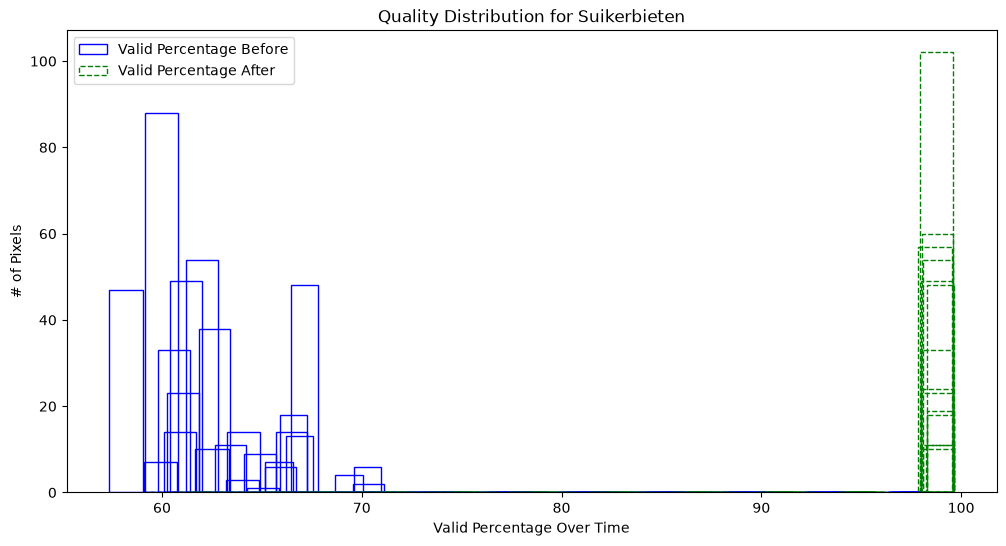

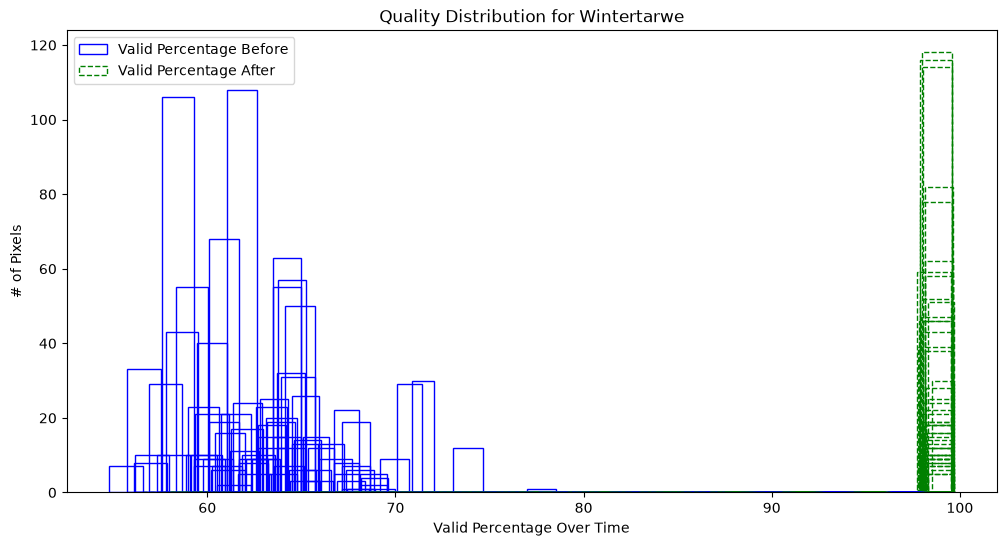

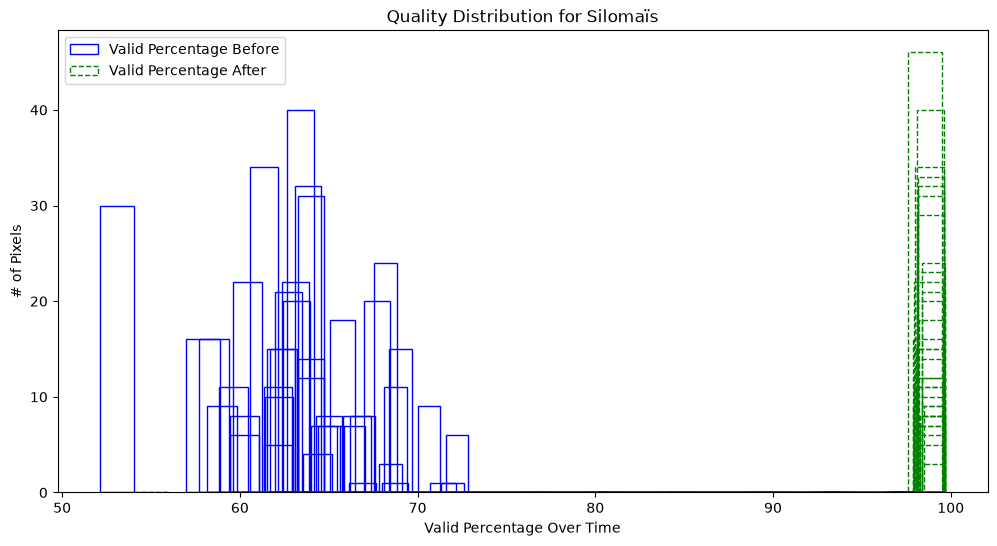

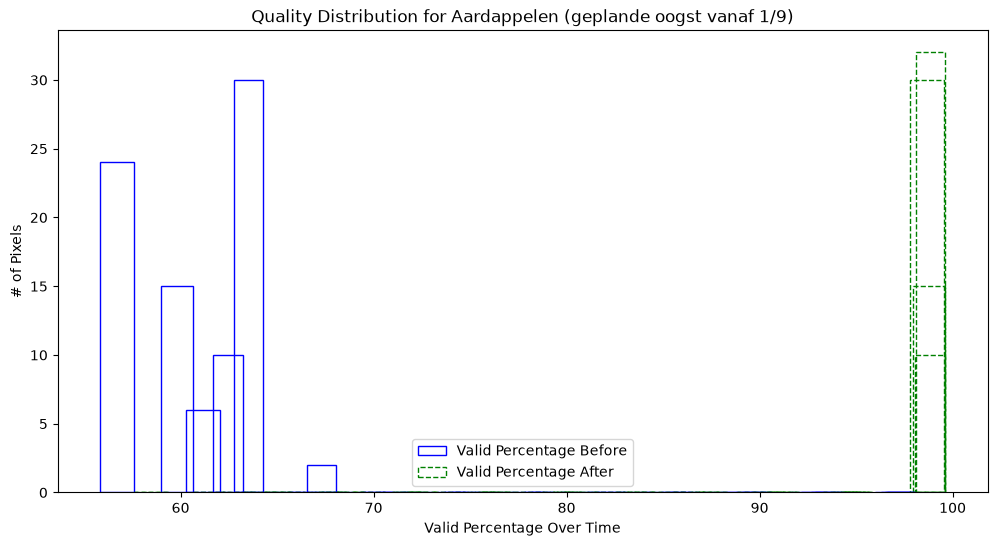

In [24]:
data_folder = "lai_quality_layers"
subset_data = subset_fields_2025[['AGPAKEY','MAINCROP']]
plot_quality_distribution(data_folder, subset_data)

## Season 2: same process as above

1. How did it look like before smoothing? (original_lai_2026)
2. How did it look like after smoothing? (smoothed_lai_2026)
3. How many valid observations were there before and after smoothing? (quality_layers_2026)

In [25]:
# aggregate to dekad to check the data before smoothing
delineated_map_2026 = delinated_lai(season2, subset_fields_2026)

without_smoothing_2026 = delineated_map_2026.aggregate_temporal_period(reducer="mean", period="dekad")
deked_job_nosmooth_2026 = without_smoothing_2026.create_job(
    title="LAI: 100 fields without smoothing (season 2)",
    sample_by_feature=True,
    feature_id_property="AGPAKEY",
    out_format="NetCDF"
)
deked_job_nosmooth_2026.start_and_wait()


0:00:00 Job 'j-2609061653434c39bb6c720f751dd846': send 'start'
0:00:14 Job 'j-2609061653434c39bb6c720f751dd846': created (progress 0%)
0:00:19 Job 'j-2609061653434c39bb6c720f751dd846': queued (progress 0%)
0:00:25 Job 'j-2609061653434c39bb6c720f751dd846': queued (progress 0%)
0:00:34 Job 'j-2609061653434c39bb6c720f751dd846': queued (progress 0%)
0:00:44 Job 'j-2609061653434c39bb6c720f751dd846': running (progress 5.0%)
0:00:57 Job 'j-2609061653434c39bb6c720f751dd846': running (progress 6.9%)
0:01:12 Job 'j-2609061653434c39bb6c720f751dd846': running (progress 9.1%)
0:01:32 Job 'j-2609061653434c39bb6c720f751dd846': running (progress 11.7%)
0:01:56 Job 'j-2609061653434c39bb6c720f751dd846': running (progress 14.7%)
0:02:26 Job 'j-2609061653434c39bb6c720f751dd846': running (progress 18.2%)
0:03:03 Job 'j-2609061653434c39bb6c720f751dd846': running (progress 22.2%)
0:03:50 Job 'j-2609061653434c39bb6c720f751dd846': running (progress 26.6%)
0:04:49 Job 'j-2609061653434c39bb6c720f751dd846': finis

<BatchJob job_id='j-2609061653434c39bb6c720f751dd846'>

In [26]:
result = deked_job_nosmooth_2026.get_results()
result.download_files("original_lai_2026/")

[WindowsPath('original_lai_2026/openEO_10262_1152550158.nc'),
 WindowsPath('original_lai_2026/openEO_10262_1211993172.nc'),
 WindowsPath('original_lai_2026/openEO_10262_1212630039.nc'),
 WindowsPath('original_lai_2026/openEO_10262_1245381178.nc'),
 WindowsPath('original_lai_2026/openEO_10262_1246799806.nc'),
 WindowsPath('original_lai_2026/openEO_10262_1247739086.nc'),
 WindowsPath('original_lai_2026/openEO_10262_1247870543.nc'),
 WindowsPath('original_lai_2026/openEO_10262_1248024531.nc'),
 WindowsPath('original_lai_2026/openEO_10262_1248462041.nc'),
 WindowsPath('original_lai_2026/openEO_10262_1248462142.nc'),
 WindowsPath('original_lai_2026/openEO_10262_1257278836.nc'),
 WindowsPath('original_lai_2026/openEO_10262_1257287728.nc'),
 WindowsPath('original_lai_2026/openEO_10262_1257420696.nc'),
 WindowsPath('original_lai_2026/openEO_10262_1257456668.nc'),
 WindowsPath('original_lai_2026/openEO_10262_1257457072.nc'),
 WindowsPath('original_lai_2026/openEO_10262_1257484253.nc'),
 Windows

In [27]:
# apply Whittaker smoothing UDF along the temporal dimension
smoothed_2026 = delineated_map_2026.apply_dimension(
    process=openeo.UDF.from_file("whittaker_udf.py"),
    dimension="t",
    context={"smoothing_lambda":10000, "prediction_period": 2},
)

# aggregate deaked after whittaker
smoothed_dekad_2026 = smoothed_2026.aggregate_temporal_period(reducer="mean", period="dekad")
deked_job_2026 = smoothed_dekad_2026.create_job(
    title="LAI:100 fields with Whittaker smoothing(season 2)",
    sample_by_feature=True,
    feature_id_property="AGPAKEY",
    out_format="NetCDF"
)
deked_job_2026.start_and_wait()


0:00:00 Job 'j-260906165923473bbd87fb9eee8643f1': send 'start'
0:00:11 Job 'j-260906165923473bbd87fb9eee8643f1': created (progress 0%)
0:00:17 Job 'j-260906165923473bbd87fb9eee8643f1': queued (progress 0%)
0:00:23 Job 'j-260906165923473bbd87fb9eee8643f1': queued (progress 0%)
0:00:31 Job 'j-260906165923473bbd87fb9eee8643f1': queued (progress 0%)
0:00:41 Job 'j-260906165923473bbd87fb9eee8643f1': queued (progress 0%)
0:00:54 Job 'j-260906165923473bbd87fb9eee8643f1': queued (progress 0%)
0:01:09 Job 'j-260906165923473bbd87fb9eee8643f1': running (progress 9.0%)
0:01:28 Job 'j-260906165923473bbd87fb9eee8643f1': running (progress 11.6%)
0:01:53 Job 'j-260906165923473bbd87fb9eee8643f1': running (progress 14.6%)
0:02:23 Job 'j-260906165923473bbd87fb9eee8643f1': running (progress 18.1%)
0:03:00 Job 'j-260906165923473bbd87fb9eee8643f1': running (progress 22.1%)
0:03:47 Job 'j-260906165923473bbd87fb9eee8643f1': running (progress 26.6%)
0:04:46 Job 'j-260906165923473bbd87fb9eee8643f1': running (pr

<BatchJob job_id='j-260906165923473bbd87fb9eee8643f1'>

In [28]:
result = deked_job_2026.get_results()
result.download_files("smoothed_lai_2026/")

[WindowsPath('smoothed_lai_2026/openEO_10262_1152550158.nc'),
 WindowsPath('smoothed_lai_2026/openEO_10262_1211993172.nc'),
 WindowsPath('smoothed_lai_2026/openEO_10262_1212630039.nc'),
 WindowsPath('smoothed_lai_2026/openEO_10262_1245381178.nc'),
 WindowsPath('smoothed_lai_2026/openEO_10262_1246799806.nc'),
 WindowsPath('smoothed_lai_2026/openEO_10262_1247739086.nc'),
 WindowsPath('smoothed_lai_2026/openEO_10262_1247870543.nc'),
 WindowsPath('smoothed_lai_2026/openEO_10262_1248024531.nc'),
 WindowsPath('smoothed_lai_2026/openEO_10262_1248462041.nc'),
 WindowsPath('smoothed_lai_2026/openEO_10262_1248462142.nc'),
 WindowsPath('smoothed_lai_2026/openEO_10262_1257278836.nc'),
 WindowsPath('smoothed_lai_2026/openEO_10262_1257287728.nc'),
 WindowsPath('smoothed_lai_2026/openEO_10262_1257420696.nc'),
 WindowsPath('smoothed_lai_2026/openEO_10262_1257456668.nc'),
 WindowsPath('smoothed_lai_2026/openEO_10262_1257457072.nc'),
 WindowsPath('smoothed_lai_2026/openEO_10262_1257484253.nc'),
 Windows

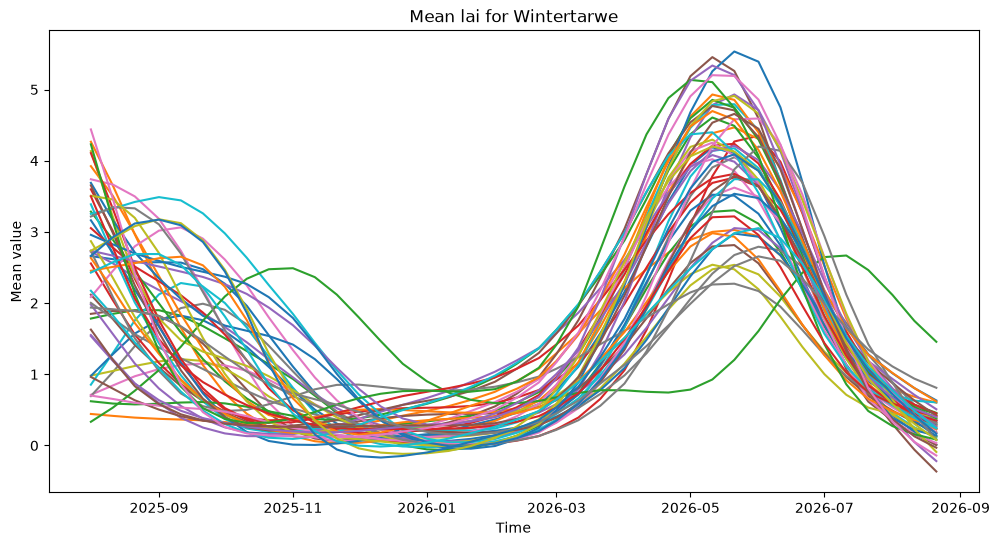

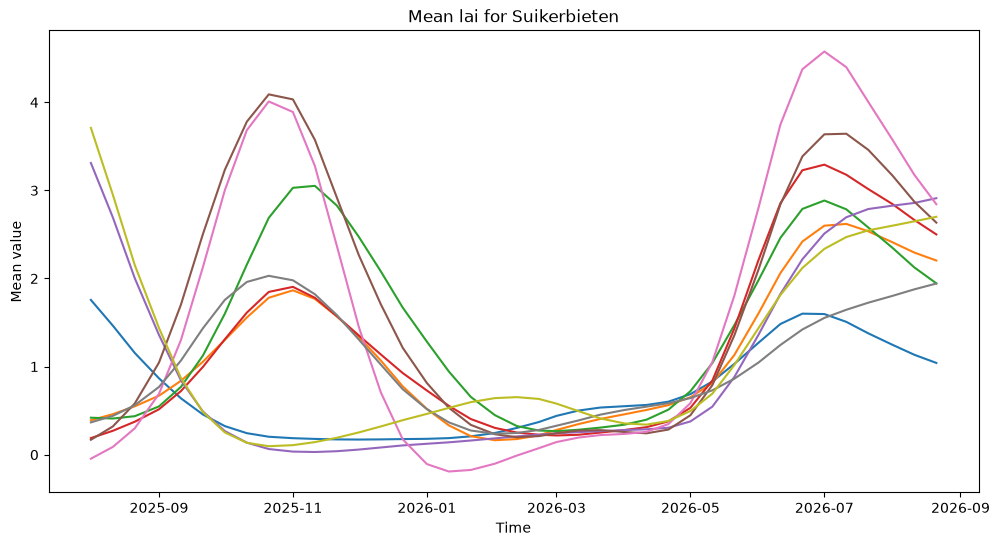

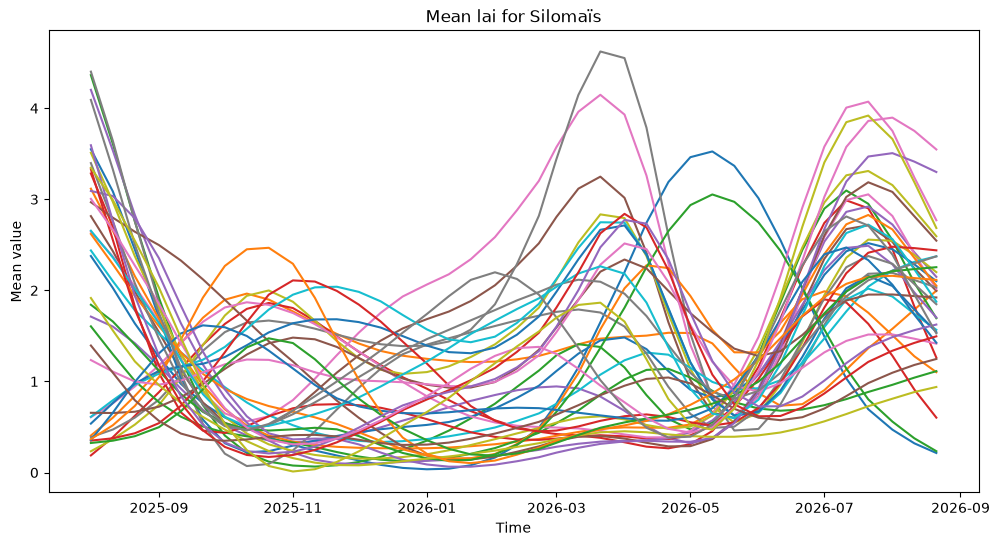

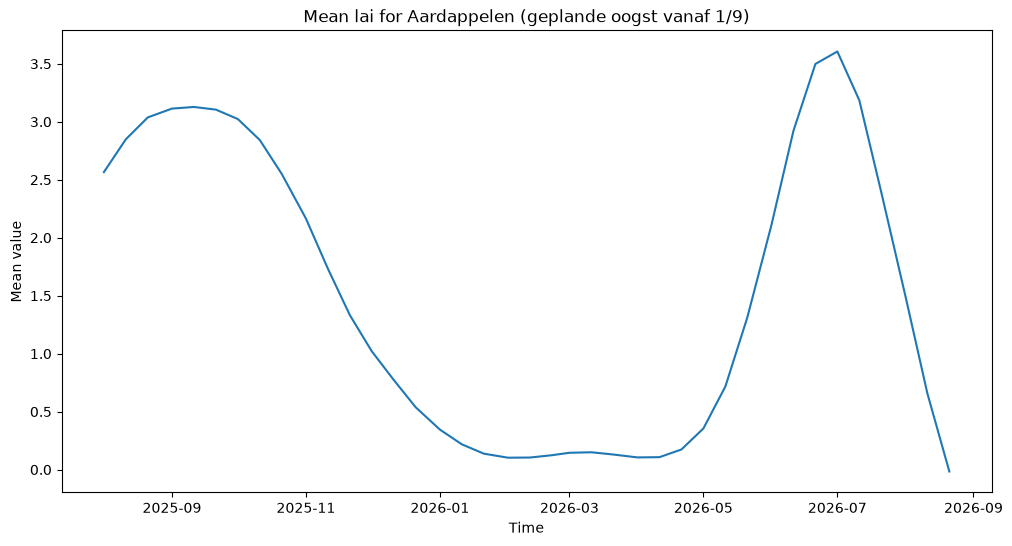

In [29]:
# season 2
data_folder = "smoothed_lai_2026"
subset_data = subset_fields_2026[['AGPAKEY','MAINCROP']]
plot_lai_per_crop_type(data_folder, subset_data)

In [31]:
# delineated_map_2026: deaked aggregation not done yet
# smoothed_2026: whittaker smoothing done deaked aggregation not done yet

valid_before_2026 = delineated_map_2026.count_time().rename_labels("bands", ["valid_before"])
all_valid_before_2026 = delineated_map_2026.apply(lambda x: if_(x.is_nodata(), 0, x))
total_before_2026 = all_valid_before_2026.count_time().rename_labels("bands", ["total_before"])

valid_after_2026 = smoothed_2026.count_time().rename_labels("bands", ["valid_after"])
all_valid_after_2026 = smoothed_2026.apply(lambda x: if_(x.is_nodata(), 0, x))
total_after_2026 = all_valid_after_2026.count_time().rename_labels("bands", ["total_after"])

In [32]:
quality_layers_2026 = valid_before_2026.merge_cubes(valid_after_2026).merge_cubes(total_before_2026).merge_cubes(total_after_2026)
quality_job_2026 = quality_layers_2026.create_job(
    title="LAI Quality Layers (Season 2)",
    sample_by_feature=True,
    feature_id_property="AGPAKEY",
    out_format="NetCDF"
)
quality_job_2026.start_and_wait()

0:00:00 Job 'j-26090617110747fe8f364fc25314375d': send 'start'
0:00:13 Job 'j-26090617110747fe8f364fc25314375d': created (progress 0%)
0:00:18 Job 'j-26090617110747fe8f364fc25314375d': queued (progress 0%)
0:00:25 Job 'j-26090617110747fe8f364fc25314375d': queued (progress 0%)
0:00:33 Job 'j-26090617110747fe8f364fc25314375d': queued (progress 0%)
0:00:43 Job 'j-26090617110747fe8f364fc25314375d': running (progress 5.0%)
0:00:56 Job 'j-26090617110747fe8f364fc25314375d': running (progress 6.8%)
0:01:11 Job 'j-26090617110747fe8f364fc25314375d': running (progress 9.0%)
0:01:31 Job 'j-26090617110747fe8f364fc25314375d': running (progress 11.6%)
0:01:55 Job 'j-26090617110747fe8f364fc25314375d': running (progress 14.7%)
0:02:25 Job 'j-26090617110747fe8f364fc25314375d': running (progress 18.2%)
0:03:02 Job 'j-26090617110747fe8f364fc25314375d': running (progress 22.2%)
0:03:49 Job 'j-26090617110747fe8f364fc25314375d': running (progress 26.6%)
0:04:48 Job 'j-26090617110747fe8f364fc25314375d': runni

<BatchJob job_id='j-26090617110747fe8f364fc25314375d'>

In [ ]:
result_2026 = quality_job_2026.get_results()
result_2026.download_files("lai_quality_layers_2026/")

In [ ]:
data_folder = "lai_quality_layers_2026"
subset_data = subset_fields_2026[['AGPAKEY','MAINCROP']]
plot_quality_distribution(data_folder, subset_data)